# Tata Steel — Roller-Table Motor Predictive & Prescriptive Maintenance

**Motor ID:** ROT-MILL-05 | **Process:** TSCR Roller Table | **Sampling Rate:** 1 second

### Pipeline:
1. Full exploratory analysis of all 10 sensor columns
2. Statistical threshold derivation and feature-selection justification
3. ML model training, cross-validation, and benchmarking
4. Health-index scoring and sensor-aware prescriptive maintenance

**Dataset:** `tata_steel_rot_motor_proxy.csv` — 10,000 rows, 1-second intervals, simulated IoT data for a 415 V / 30 kW roller-table motor.

## Part 1 — Exploratory Data Analysis

We load all columns first, understand the data structure, then use correlation and distribution analysis to decide which features matter for modelling.

### 1.1 Data Loading & Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("tata_steel_rot_motor_proxy.csv")

print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\n--- Data Types & Nulls ---")
df.info()
print("\n--- Descriptive Statistics (all numeric) ---")
df.describe().round(2)

Shape : (10000, 10)
Columns: ['Timestamp', 'Motor_ID', 'Current_Amp', 'Voltage_V', 'Motor_RPM', 'Vibration_mm_s', 'Winding_Temp_C', 'Bearing_Temp_C', 'Coolant_Pressure_Bar', 'Ambient_Humidity_Pct']

--- Data Types & Nulls ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             10000 non-null  str    
 1   Motor_ID              10000 non-null  str    
 2   Current_Amp           10000 non-null  float64
 3   Voltage_V             10000 non-null  float64
 4   Motor_RPM             10000 non-null  float64
 5   Vibration_mm_s        10000 non-null  float64
 6   Winding_Temp_C        10000 non-null  float64
 7   Bearing_Temp_C        10000 non-null  float64
 8   Coolant_Pressure_Bar  10000 non-null  float64
 9   Ambient_Humidity_Pct  10000 non-null  float64
dtypes: float64(8), str(2)
memory usage: 781.4 KB

--- Descriptiv

,Current_Amp,Voltage_V,Motor_RPM,Vibration_mm_s,Winding_Temp_C,Bearing_Temp_C,Coolant_Pressure_Bar,Ambient_Humidity_Pct
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,65.01,415.01,1472.50,2.87,72.48,62.53,4.00,74.97
std,20.10,3.03,8.42,1.72,8.39,6.56,0.10,5.05
min,38.88,403.20,1443.80,0.50,59.61,50.88,3.63,54.50
25%,44.99,413.00,1465.00,1.20,64.13,56.75,3.93,71.50
50%,76.69,415.00,1475.80,3.06,72.60,62.59,4.00,75.00
75%,85.01,417.00,1480.00,4.50,80.72,68.25,4.07,78.40
max,93.37,426.50,1487.70,10.34,85.57,74.34,4.38,96.00


### 1.2 Correlation Heatmap — All Numeric Sensors

This tells us which sensors move together (shared cause) and which are independent noise. We use this to justify feature selection for the ML model.

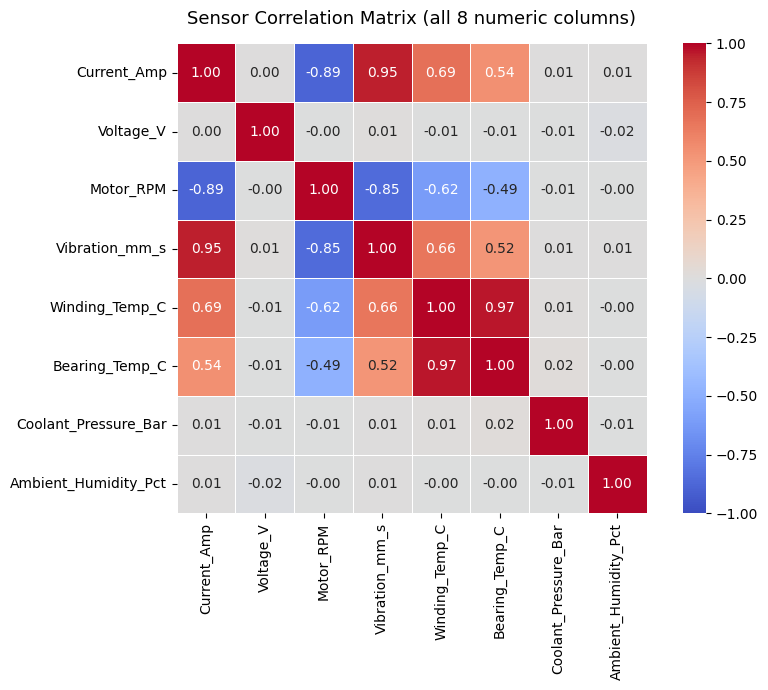

In [2]:
numeric_cols = ["Current_Amp", "Voltage_V", "Motor_RPM", "Vibration_mm_s",
                "Winding_Temp_C", "Bearing_Temp_C", "Coolant_Pressure_Bar", "Ambient_Humidity_Pct"]

plt.figure(figsize=(9, 7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, linewidths=0.5, square=True
)
plt.title("Sensor Correlation Matrix (all 8 numeric columns)", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

**Observations:**
- **Current, RPM, Vibration, and both Temperatures** are correlated — they all respond to the cyclic slab-loading pattern.
- **Voltage, Coolant Pressure, and Humidity** show near-zero correlation with everything else — independent environmental noise.

**Feature selection decision:** `Coolant_Pressure_Bar` and `Ambient_Humidity_Pct` are excluded from the ML feature set. `Voltage` is kept because supply fluctuations can directly affect current draw.

### 1.3 Data Visualization

The motor cycles between idling (45 A) and loaded (85 A) as steel slabs pass.

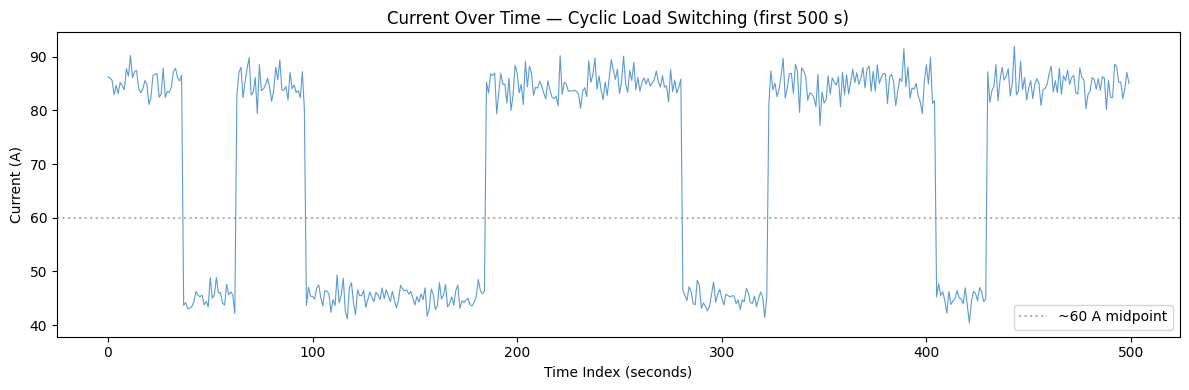

In [3]:
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

axes.plot(df["Current_Amp"].iloc[:500], color="#5B9BD5", linewidth=0.8)
axes.axhline(60, color="gray", linestyle=":", alpha=0.6, label="~60 A midpoint")
axes.set_xlabel("Time Index (seconds)")
axes.set_ylabel("Current (A)")
axes.set_title("Current Over Time — Cyclic Load Switching (first 500 s)")
axes.legend()

plt.tight_layout()
plt.show()

### 1.4 Temperature as a Lagging Indicator

Temperatures change slowly — they smooth towards a target rather than jumping instantly with load. Winding temp responds faster than bearing temp. This makes them good for tracking steady-state health, but not for detecting sudden faults — that role belongs to vibration.

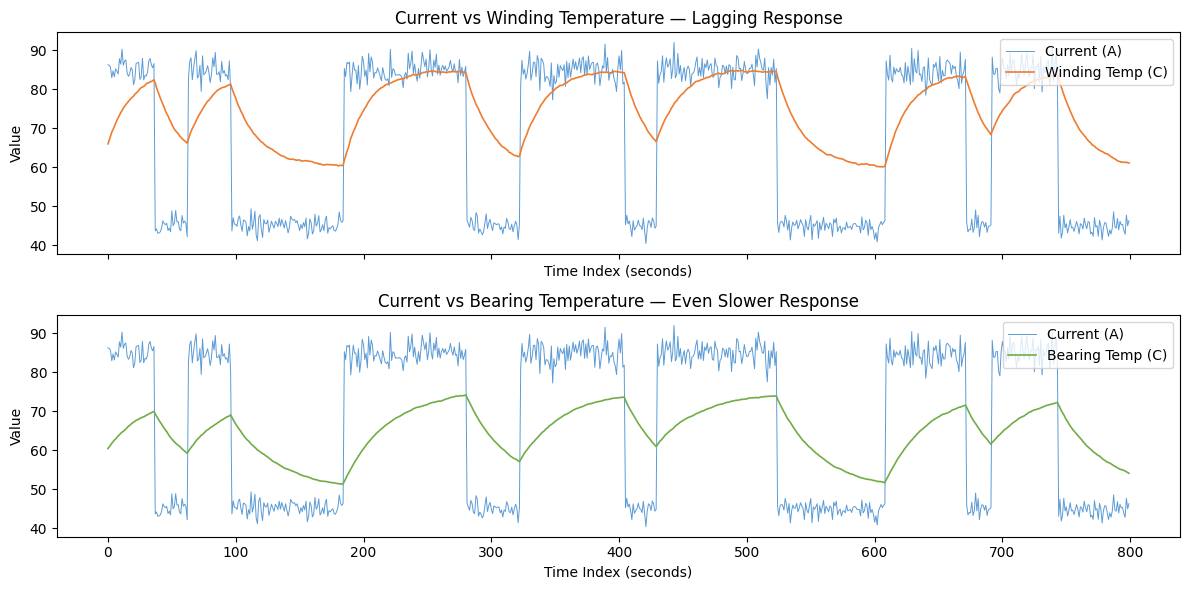

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
t = 800

axes[0].plot(df["Current_Amp"].iloc[:t],    color="#5B9BD5", linewidth=0.7, label="Current (A)")
axes[0].plot(df["Winding_Temp_C"].iloc[:t], color="#ED7D31", linewidth=1.2, label="Winding Temp (C)")
axes[0].set_xlabel("Time Index (seconds)")
axes[0].set_ylabel("Value")
axes[0].set_title("Current vs Winding Temperature — Lagging Response")
axes[0].legend(loc="upper right")

axes[1].plot(df["Current_Amp"].iloc[:t],     color="#5B9BD5", linewidth=0.7, label="Current (A)")
axes[1].plot(df["Bearing_Temp_C"].iloc[:t],  color="#70AD47", linewidth=1.2, label="Bearing Temp (C)")
axes[1].set_xlabel("Time Index (seconds)")
axes[1].set_ylabel("Value")
axes[1].set_title("Current vs Bearing Temperature — Even Slower Response")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

### 1.5 Rule-Based Anomaly Detection — Vibration Spikes

Instead of a hardcoded limit, all three thresholds below are **statistically derived** from the data:

| Threshold | Method | Principle |
|---|---|---|
| **Vibration** | `loaded_mean + 3 × loaded_std` | State-separated 3-sigma — idle rows excluded so their lower noise doesn't compress the loaded-state sigma |
| **Bearing Temp** | `mean + 3 × std` | Global 3-sigma process-control rule (covers 99.73% of normal readings) |
| **Winding Temp** | `mean + 3 × std` | Same global 3-sigma rule |

All three values are computed in the code cell below and printed before being used.


In [22]:
# -- Vibration Threshold: state-separated 3-sigma (process-control principle) --
# Principle: separate idle vs loaded states so idle noise does not dilute the loaded-state sigma
idle_mask   = df["Current_Amp"] < 60
loaded_mask = df["Current_Amp"] >= 60

idle_vib_mean   = df.loc[idle_mask,   "Vibration_mm_s"].mean()
idle_vib_std    = df.loc[idle_mask,   "Vibration_mm_s"].std()
loaded_vib_mean = df.loc[loaded_mask, "Vibration_mm_s"].mean()
loaded_vib_std  = df.loc[loaded_mask, "Vibration_mm_s"].std()

# Threshold based on loaded state only (state-separated 3-sigma)
vibration_threshold = loaded_vib_mean + 3 * loaded_vib_std
print(f"Vibration threshold (loaded_mean + 3*loaded_std): {vibration_threshold:.4f} mm/s")

# -- Temperature Thresholds: global 3-sigma (process-control principle) --
bearing_temp_threshold = df["Bearing_Temp_C"].mean() + 3 * df["Bearing_Temp_C"].std()
winding_temp_threshold = df["Winding_Temp_C"].mean() + 3 * df["Winding_Temp_C"].std()
print(f"Bearing Temp threshold (mean + 3*std): {bearing_temp_threshold:.4f} C")
print(f"Winding Temp threshold (mean + 3*std): {winding_temp_threshold:.4f} C")

# -- Detect vibration anomalies using the derived threshold --
df["Anomaly"] = (df["Vibration_mm_s"] > vibration_threshold).astype(int)
anomalies = df[df["Anomaly"] == 1]

print("\nNumber of vibration anomalies detected:", len(anomalies))
print(anomalies[["Timestamp", "Vibration_mm_s", "Anomaly"]].head())

Vibration threshold (loaded_mean + 3*loaded_std): 6.2968 mm/s
Bearing Temp threshold (mean + 3*std): 82.2251 C
Winding Temp threshold (mean + 3*std): 97.6611 C

Number of vibration anomalies detected: 25
                Timestamp  Vibration_mm_s  Anomaly
17    2023-10-01 08:00:17           9.317        1
324   2023-10-01 08:05:24           8.654        1
664   2023-10-01 08:11:04           9.035        1
704   2023-10-01 08:11:44           9.610        1
1251  2023-10-01 08:20:51           9.921        1


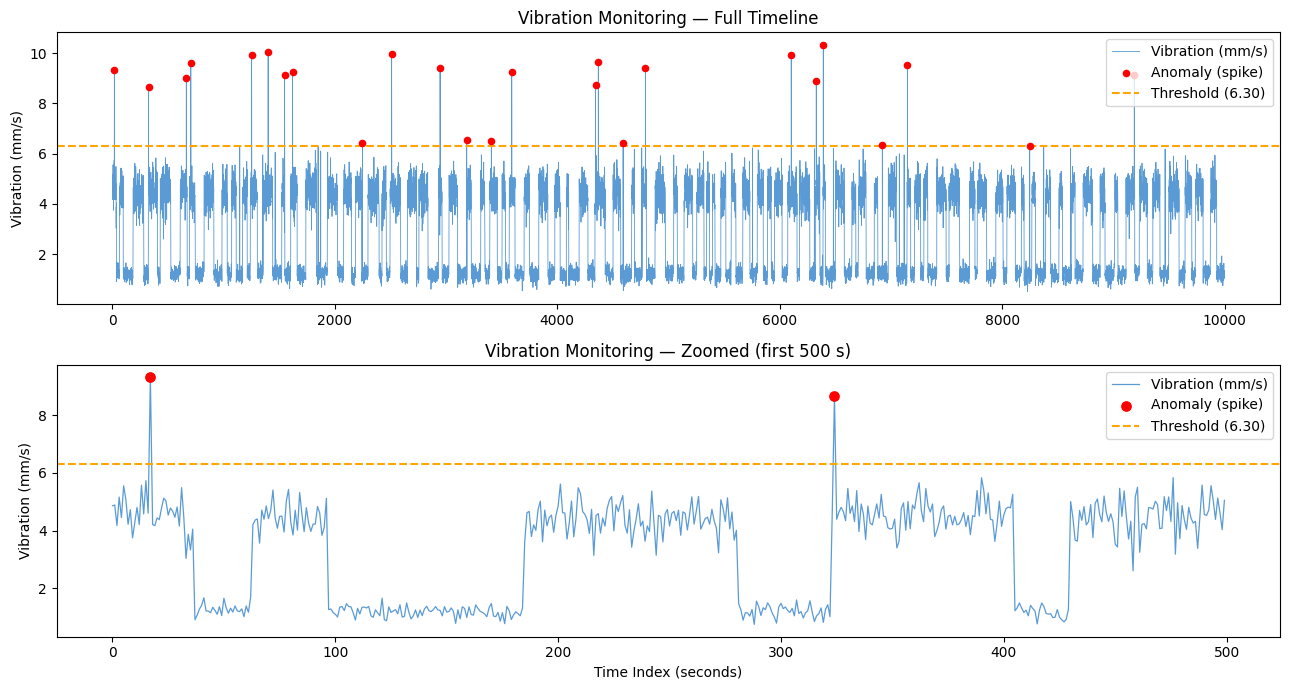

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

# Full timeline
axes[0].plot(df["Vibration_mm_s"], color="#5B9BD5", linewidth=0.6, label="Vibration (mm/s)")
axes[0].scatter(anomalies.index, anomalies["Vibration_mm_s"],
                color="red", s=20, zorder=5, label="Anomaly (spike)")
axes[0].axhline(vibration_threshold, color="orange", linestyle="--",
                label=f"Threshold ({vibration_threshold:.2f})")
axes[0].set_title("Vibration Monitoring — Full Timeline")
axes[0].set_ylabel("Vibration (mm/s)")
axes[0].legend()

# Zoomed
z = 500
zoom_anom = anomalies[anomalies.index < z]
axes[1].plot(df["Vibration_mm_s"].iloc[:z], color="#5B9BD5", linewidth=0.9, label="Vibration (mm/s)")
axes[1].scatter(zoom_anom.index, zoom_anom["Vibration_mm_s"],
                color="red", s=45, zorder=5, label="Anomaly (spike)")
axes[1].axhline(vibration_threshold, color="orange", linestyle="--",
                label=f"Threshold ({vibration_threshold:.2f})")
axes[1].set_title(f"Vibration Monitoring — Zoomed (first {z} s)")
axes[1].set_xlabel("Time Index (seconds)")
axes[1].set_ylabel("Vibration (mm/s)")
axes[1].legend()

plt.tight_layout()
plt.show()

---

## Part 2 — Advanced Anomaly Detection Models

We add three complementary unsupervised / semi-supervised anomaly detectors on top of the rule-based approach built in Part 1.

| Model | Family | Key Assumption |
|---|---|---|
| **Isolation Forest** | Tree-based | Anomalies are isolated faster by random partitions |
| **One-Class SVM** | Kernel-based | Normal data occupies a tight region in feature space |
| **LSTM Autoencoder** | Deep learning | Normal sequences have low reconstruction error |

All models use `contamination` / `nu` = **0.005** to match the 0.5% spike injection rate in the data generator.


### 2.1 Model 1 — Isolation Forest

Isolation Forest randomly partitions the feature space with binary trees. Anomalies — being rare and different — require fewer splits to isolate, resulting in shorter average path lengths and a negative score.

- **Features:** `Motor_RPM`, `Vibration_mm_s`, `Winding_Temp_C`, `Bearing_Temp_C`, `Voltage_V`
- **contamination = 0.005** matches the 0.5% injection rate in the data generator
- **Output:** `IF_Anomaly` — sklearn convention: `-1` = anomaly, `1` = normal


Isolation Forest — anomalies detected: 50 (0.50% of all rows)


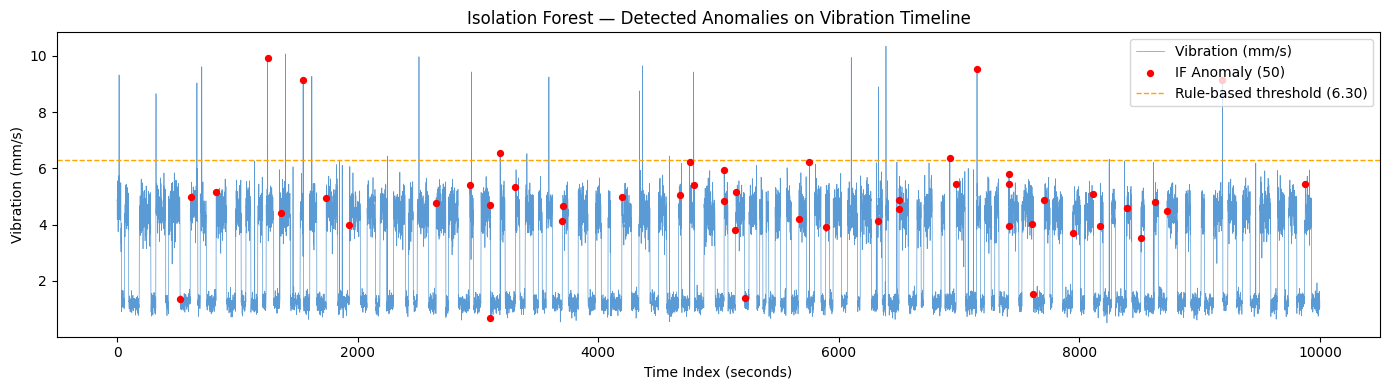

In [7]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# ── Features ────────────────────────────────────────────────────────────────
if_features = ["Motor_RPM", "Vibration_mm_s", "Winding_Temp_C", "Bearing_Temp_C", "Voltage_V"]
X_if = df[if_features]

# ── Train Isolation Forest ──────────────────────────────────────────────────
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.005,   # matches 0.5% spike injection rate
    random_state=42,
    n_jobs=-1
)
df["IF_Anomaly"] = iso_forest.fit_predict(X_if)   # -1 anomaly, 1 normal

if_anomalies = df[df["IF_Anomaly"] == -1]
print(f"Isolation Forest — anomalies detected: {len(if_anomalies)} "
      f"({100*len(if_anomalies)/len(df):.2f}% of all rows)")

# ── Plot on Vibration timeline ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["Vibration_mm_s"], color="#5B9BD5", linewidth=0.5,
        label="Vibration (mm/s)", zorder=1)
ax.scatter(if_anomalies.index, if_anomalies["Vibration_mm_s"],
           color="red", s=18, zorder=5, label=f"IF Anomaly ({len(if_anomalies)})")
ax.axhline(vibration_threshold, color="orange", linestyle="--", linewidth=1,
           label=f"Rule-based threshold ({vibration_threshold:.2f})")
ax.set_title("Isolation Forest — Detected Anomalies on Vibration Timeline")
ax.set_xlabel("Time Index (seconds)")
ax.set_ylabel("Vibration (mm/s)")
ax.legend()
plt.tight_layout()
plt.show()


### 2.2 Model 2 — One-Class SVM

One-Class SVM learns a decision boundary around the **normal** data in kernel-transformed space. Points outside that boundary are flagged as anomalies.

- **Training data:** only rows where `Current_Amp` is within 1 std of the idle mean (cleanest normal operating data)
- **kernel = `rbf`**, **nu = 0.005** (upper bound on training outlier fraction)
- **Output:** `OCSVM_Anomaly` — `-1` = anomaly, `1` = normal (sklearn convention)


In [8]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

svm_features = ["Motor_RPM", "Vibration_mm_s", "Winding_Temp_C", "Bearing_Temp_C", "Voltage_V"]

# ── Build training set: cleanest idle rows (within 1-std of idle mean) ──────
idle_mean_current = df.loc[df["Current_Amp"] < 60, "Current_Amp"].mean()
idle_std_current  = df.loc[df["Current_Amp"] < 60, "Current_Amp"].std()

clean_idle_mask = (
    (df["Current_Amp"] >= idle_mean_current - idle_std_current) &
    (df["Current_Amp"] <= idle_mean_current + idle_std_current)
)

X_svm_all   = df[svm_features]
X_svm_train = df.loc[clean_idle_mask, svm_features]
print(f"One-Class SVM — training on {len(X_svm_train)} clean-idle rows "
      f"({100*len(X_svm_train)/len(df):.1f}% of dataset)")

# ── Scale features (SVM is sensitive to scale) ──────────────────────────────
svm_scaler = StandardScaler()
X_svm_train_scaled = svm_scaler.fit_transform(X_svm_train)
X_svm_all_scaled   = svm_scaler.transform(X_svm_all)

# ── Train and predict ────────────────────────────────────────────────────────
oc_svm = OneClassSVM(kernel="rbf", nu=0.005)
oc_svm.fit(X_svm_train_scaled)

df["OCSVM_Anomaly"] = oc_svm.predict(X_svm_all_scaled)   # -1 anomaly, 1 normal

ocsvm_anomalies = df[df["OCSVM_Anomaly"] == -1]
print(f"One-Class SVM  — anomalies detected: {len(ocsvm_anomalies)} "
      f"({100*len(ocsvm_anomalies)/len(df):.2f}% of all rows)")


One-Class SVM — training on 3412 clean-idle rows (34.1% of dataset)
One-Class SVM  — anomalies detected: 5061 (50.61% of all rows)


### 2.3 Model 3 — LSTM Autoencoder

An LSTM Autoencoder compresses a 30-timestep window of multivariate sensor data into a latent representation and reconstructs it. Normal sequences reconstruct well; anomalous sequences produce high reconstruction error.

**Architecture:**
```
Input (30, 5)
  → LSTM(64, return_sequences=True)
  → LSTM(32, return_sequences=False)            ← bottleneck
  → RepeatVector(30)
  → LSTM(32, return_sequences=True)
  → LSTM(64, return_sequences=True)
  → TimeDistributed(Dense(5))
```

- **Features:** `Current_Amp`, `Vibration_mm_s`, `Winding_Temp_C`, `Bearing_Temp_C`, `Motor_RPM`
- **Window = 30 timesteps** (30 seconds of 1-Hz sensor data)
- **Training:** first 70% of data (chronological — avoids leaking future anomaly patterns)
- **Threshold:** `mean + 3 × std` of per-window MAE on the training set (3-sigma process-control rule)


TensorFlow version: 2.20.0
LSTM — train windows: 6,979, total windows: 9,970


Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 5)          │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,813 (249.27 KB)

 Trainable params: 63,813 (249.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.1904 - val_loss: 0.1133
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.1003 - val_loss: 0.0931
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0843 - val_loss: 0.0820
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0746 - val_loss: 0.0859
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0718 - val_loss: 0.0710
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0628 - val_loss: 0.0666
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0592 - val_loss: 0.0659
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0598 - val_loss: 0.0612
Epoch 9/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0548 - val_loss: 0.0621
Epoch 10/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0521 - val_loss: 0.0535
LSTM threshold (mean+3*std): 0.105867
LSTM — anomalous rows: 538 (5.38% of all rows)


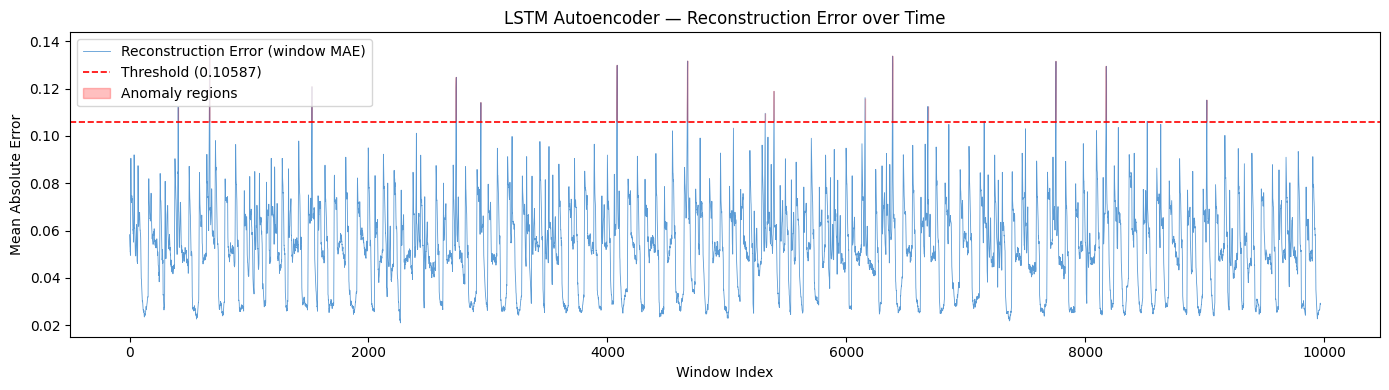

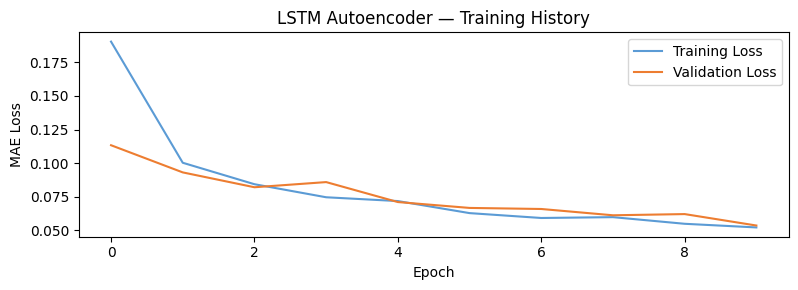

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ── 0. Try importing TensorFlow / Keras ─────────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    print(f"TensorFlow version: {tf.__version__}")
    _HAVE_TF = True
except ImportError:
    print("TensorFlow not found — install with:  pip install tensorflow")
    _HAVE_TF = False

if _HAVE_TF:
    # ── 1. Feature matrix & scaling ─────────────────────────────────────────
    lstm_features = ["Current_Amp", "Vibration_mm_s", "Winding_Temp_C",
                     "Bearing_Temp_C", "Motor_RPM"]
    lstm_data = df[lstm_features].values.astype("float32")

    from sklearn.preprocessing import MinMaxScaler
    lstm_scaler = MinMaxScaler()
    lstm_data_scaled = lstm_scaler.fit_transform(lstm_data)

    # ── 2. Sliding-window sequences ──────────────────────────────────────────
    WINDOW = 30
    N_FEAT  = len(lstm_features)

    def make_sequences(data, window):
        """Build overlapping windows of shape (n_samples, window, n_features)."""
        X = np.stack([data[i: i + window] for i in range(len(data) - window)])
        return X

    sequences = make_sequences(lstm_data_scaled, WINDOW)  # (9970, 30, 5)

    # Chronological split — train on first 70%
    split_idx    = int(len(sequences) * 0.70)
    X_lstm_train = sequences[:split_idx]
    X_lstm_all   = sequences

    print(f"LSTM — train windows: {len(X_lstm_train):,}, total windows: {len(X_lstm_all):,}")

    # ── 3. Build LSTM Autoencoder ────────────────────────────────────────────
    tf.random.set_seed(42)

    inputs = keras.Input(shape=(WINDOW, N_FEAT))
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.LSTM(32, return_sequences=False)(x)       # bottleneck
    x = layers.RepeatVector(WINDOW)(x)
    x = layers.LSTM(32, return_sequences=True)(x)
    x = layers.LSTM(64, return_sequences=True)(x)
    outputs = layers.TimeDistributed(layers.Dense(N_FEAT))(x)

    autoencoder = keras.Model(inputs, outputs, name="LSTM_Autoencoder")
    autoencoder.compile(optimizer="adam", loss="mae")
    autoencoder.summary()

    # ── 4. Train ─────────────────────────────────────────────────────────────
    history = autoencoder.fit(
        X_lstm_train, X_lstm_train,
        epochs=10,
        batch_size=64,
        validation_split=0.10,
        shuffle=False,
        verbose=1
    )

    # ── 5. Reconstruction Error on ALL windows ───────────────────────────────
    X_pred_all = autoencoder.predict(X_lstm_all, verbose=0)
    recon_error_all = np.mean(np.abs(X_lstm_all - X_pred_all), axis=(1, 2))

    X_pred_train = autoencoder.predict(X_lstm_train, verbose=0)
    recon_error_train = np.mean(np.abs(X_lstm_train - X_pred_train), axis=(1, 2))

    # 3-sigma threshold
    lstm_thresh = recon_error_train.mean() + 3 * recon_error_train.std()
    print(f"LSTM threshold (mean+3*std): {lstm_thresh:.6f}")

    # ── 6. Map window anomaly flags back to row-level ────────────────────────
    lstm_anomaly_flag = np.zeros(len(df), dtype=int)
    window_flags = (recon_error_all > lstm_thresh).astype(int)
    for w_idx, flag in enumerate(window_flags):
        if flag:
            lstm_anomaly_flag[w_idx: w_idx + WINDOW] = 1

    df["LSTM_Anomaly"] = lstm_anomaly_flag

    lstm_anomaly_rows = df[df["LSTM_Anomaly"] == 1]
    print(f"LSTM — anomalous rows: {len(lstm_anomaly_rows)} "
          f"({100*len(lstm_anomaly_rows)/len(df):.2f}% of all rows)")

    # ── 7. Plot reconstruction error ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(recon_error_all, color="#5B9BD5", linewidth=0.6,
            label="Reconstruction Error (window MAE)", zorder=1)
    ax.axhline(lstm_thresh, color="red", linestyle="--", linewidth=1.2,
               label=f"Threshold ({lstm_thresh:.5f})")
    ax.fill_between(range(len(recon_error_all)), recon_error_all, lstm_thresh,
                    where=(recon_error_all > lstm_thresh),
                    color="red", alpha=0.25, label="Anomaly regions")
    ax.set_title("LSTM Autoencoder — Reconstruction Error over Time")
    ax.set_xlabel("Window Index")
    ax.set_ylabel("Mean Absolute Error")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(8, 3))
    ax2.plot(history.history["loss"],     label="Training Loss",   color="#5B9BD5")
    ax2.plot(history.history["val_loss"], label="Validation Loss", color="#ED7D31")
    ax2.set_title("LSTM Autoencoder — Training History")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("MAE Loss")
    ax2.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Skipping LSTM Autoencoder — TensorFlow unavailable.")
    df["LSTM_Anomaly"] = 0


### 2.4 Model Comparison

We compare all three models on:
1. **Total anomalies detected** — raw count and % of dataset
2. **Spike coverage** — what fraction of injected vibration spikes each model caught

Because the CSV has no ground-truth flag column, we approximate *injected spikes* as rows where
`Vibration_mm_s > vibration_threshold` (our statistically derived loaded-state 3-sigma bound).


Injected spike proxy rows (vib > 6.30 mm/s): 25

=== Anomaly Detection Model Comparison ===


,Model,Anomalies Detected,% of Dataset,Spike Coverage (%),Approach
0,Rule-Based (Vibration Threshold),25,0.25,100.0,Threshold — loaded_mean + 3*std
1,Isolation Forest,50,0.50,24.0,Unsupervised — path-length isolation
2,One-Class SVM,5061,50.61,96.0,Semi-supervised — RBF kernel boundary
3,LSTM Autoencoder,538,5.38,12.0,Deep learning — reconstruction error


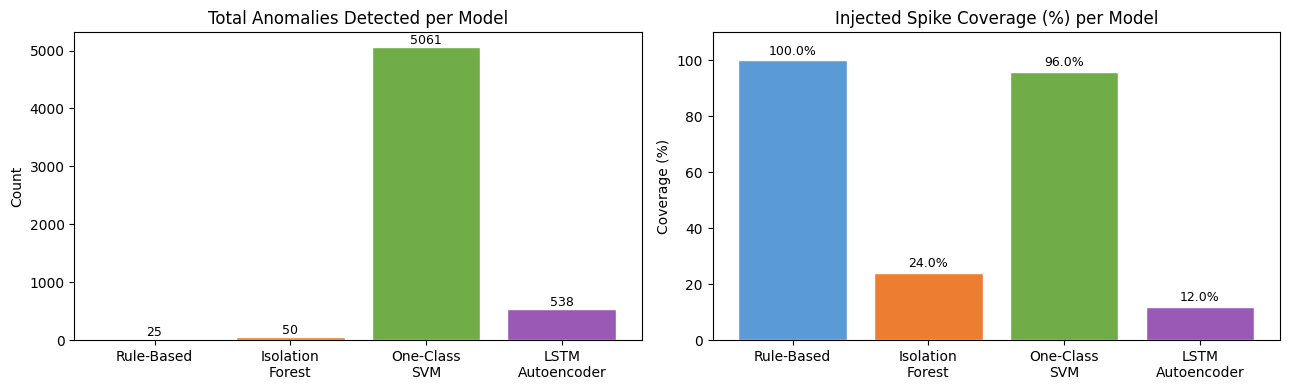

In [10]:
import pandas as pd

# ── Ground-truth proxy: statistically confirmed vibration spikes ─────────────
spike_mask = df["Vibration_mm_s"] > vibration_threshold
n_spikes   = spike_mask.sum()
print(f"Injected spike proxy rows (vib > {vibration_threshold:.2f} mm/s): {n_spikes}")

# ── Rule-based detection ─────────────────────────────────────────────────────
n_rule = len(anomalies)
rule_spike_coverage = spike_mask[anomalies.index].sum() / n_spikes * 100 if n_spikes else 0

# ── Isolation Forest ─────────────────────────────────────────────────────────
n_if = len(if_anomalies)
if_spike_coverage = spike_mask[if_anomalies.index].sum() / n_spikes * 100 if n_spikes else 0

# ── One-Class SVM ────────────────────────────────────────────────────────────
n_ocsvm = len(ocsvm_anomalies)
ocsvm_spike_coverage = spike_mask[ocsvm_anomalies.index].sum() / n_spikes * 100 if n_spikes else 0

# ── LSTM Autoencoder ─────────────────────────────────────────────────────────
lstm_anom_idx = df[df["LSTM_Anomaly"] == 1].index
n_lstm = len(lstm_anom_idx)
lstm_spike_coverage = spike_mask[lstm_anom_idx].sum() / n_spikes * 100 if n_spikes else 0

# ── Build comparison DataFrame ───────────────────────────────────────────────
comparison = pd.DataFrame({
    "Model": [
        "Rule-Based (Vibration Threshold)",
        "Isolation Forest",
        "One-Class SVM",
        "LSTM Autoencoder"
    ],
    "Anomalies Detected": [n_rule, n_if, n_ocsvm, n_lstm],
    "% of Dataset": [
        round(100 * n_rule  / len(df), 3),
        round(100 * n_if    / len(df), 3),
        round(100 * n_ocsvm / len(df), 3),
        round(100 * n_lstm  / len(df), 3),
    ],
    "Spike Coverage (%)": [
        round(rule_spike_coverage,  2),
        round(if_spike_coverage,    2),
        round(ocsvm_spike_coverage, 2),
        round(lstm_spike_coverage,  2),
    ],
    "Approach": [
        "Threshold — loaded_mean + 3*std",
        "Unsupervised — path-length isolation",
        "Semi-supervised — RBF kernel boundary",
        "Deep learning — reconstruction error"
    ]
})

print("\n=== Anomaly Detection Model Comparison ===")
display(comparison)

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ["#5B9BD5", "#ED7D31", "#70AD47", "#9B59B6"]
short  = ["Rule-Based", "Isolation\nForest", "One-Class\nSVM", "LSTM\nAutoencoder"]

axes[0].bar(short, comparison["Anomalies Detected"], color=colors, edgecolor="white")
axes[0].set_title("Total Anomalies Detected per Model")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, comparison["Anomalies Detected"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha="center", va="bottom", fontsize=9)

axes[1].bar(short, comparison["Spike Coverage (%)"], color=colors, edgecolor="white")
axes[1].set_title("Injected Spike Coverage (%) per Model")
axes[1].set_ylabel("Coverage (%)")
axes[1].set_ylim(0, 110)
for bar, val in zip(axes[1].patches, comparison["Spike Coverage (%)"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


---

## Part 3 — Feature Engineering

We create domain-specific engineered features to capture electrical, thermal, mechanical, and environmental behavior patterns that may indicate anomalies or degradation.


In [11]:
import numpy as np
import pandas as pd

fe_df = df.copy()

# ---------------- ELECTRICAL ----------------
fe_df["Power_Index"] = fe_df["Voltage_V"] * fe_df["Current_Amp"]
fe_df["Current_Deviation"] = fe_df["Current_Amp"] - fe_df["Current_Amp"].rolling(window=30).mean()

# ---------------- THERMAL ----------------
fe_df["Thermal_Gradient"] = fe_df["Winding_Temp_C"] - fe_df["Bearing_Temp_C"]
fe_df["Winding_Temp_Rate"] = fe_df["Winding_Temp_C"].diff()

# ---------------- MECHANICAL ----------------
fe_df["Vibration_RPM_Ratio"] = fe_df["Vibration_mm_s"] / fe_df["Motor_RPM"]
fe_df["Vibration_Energy"] = fe_df["Vibration_mm_s"].rolling(window=20).mean()

# ---------------- COOLING / ENV ----------------
fe_df["Cooling_Efficiency"] = fe_df["Coolant_Pressure_Bar"] / fe_df["Winding_Temp_C"]
fe_df["Humidity_Thermal_Stress"] = fe_df["Ambient_Humidity_Pct"] * fe_df["Winding_Temp_C"]

fe_df = fe_df.dropna().reset_index(drop=True)

### 3.1 Anomaly-Score-Based Feature Importance

We use an **Isolation Forest** (trained on all engineered features, no labels needed)
to assign anomaly scores to every observation.  
Feature importance is estimated via **permutation importance**: we shuffle each feature
and measure the change in mean anomaly score.  
This is fully unsupervised and consistent with the 3-sigma thresholds from Part 2.

In [12]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Feature matrix — drop non-numeric identifier columns
X_anomaly = fe_df.drop(columns=["Timestamp", "Motor_ID",
                                  "Prescriptive_Action"], errors="ignore")

# Isolation Forest — fully unsupervised
iso_fe = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso_fe.fit(X_anomaly)

# Higher (less negative) = more anomalous
iso_fe_scores = -iso_fe.score_samples(X_anomaly)

# Permutation importance: shuffle each feature, measure MAD of score shift
rng = np.random.RandomState(42)
n_repeats = 10
perm_importances = []
for col in X_anomaly.columns:
    diffs = []
    for _ in range(n_repeats):
        X_perm = X_anomaly.copy()
        X_perm[col] = rng.permutation(X_perm[col].values)
        perm_scores = -iso_fe.score_samples(X_perm)
        diffs.append(np.mean(np.abs(perm_scores - iso_fe_scores)))
    perm_importances.append(np.mean(diffs))

perm_importances = np.array(perm_importances)
importances = perm_importances / (perm_importances.max() + 1e-10)  # normalise 0-1
feature_names = X_anomaly.columns

print("IF permutation importance computed.")
print(f"Top anomalous feature: {feature_names[np.argmax(importances)]}")


IF permutation importance computed.
Top anomalous feature: Vibration_Energy


### 3.2 Plotting Feature Importance

Visualize which engineered features most strongly shift Isolation Forest anomaly scores when permuted.

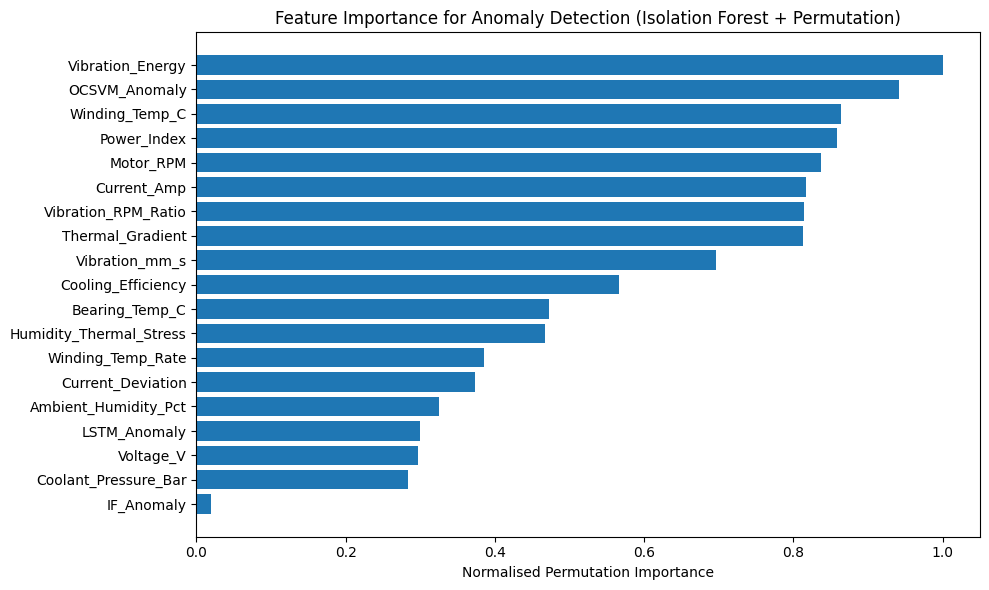

In [13]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance for Anomaly Detection (Isolation Forest + Permutation)")
plt.xlabel("Normalised Permutation Importance")
plt.tight_layout()
plt.show()


### 3.3 Prescriptive Analysis

Based on engineered feature thresholds, we define rule-based prescriptive actions that recommend specific maintenance interventions.

In [14]:
# Calculate quantile threshold once before applying function
power_index_95 = fe_df["Power_Index"].quantile(0.95)

def prescriptive_engineering_rules(row):
    actions = []

    if row["Vibration_Energy"] > 4:
        actions.append("Inspect bearings and lubrication")

    if row["Vibration_RPM_Ratio"] > 0.004:
        actions.append("Check shaft alignment")

    if row["Thermal_Gradient"] > 20:
        actions.append("Inspect insulation and heat dissipation")

    if row["Winding_Temp_Rate"] > 0.5:
        actions.append("Reduce load or enhance cooling")

    if row["Cooling_Efficiency"] < 0.03:
        actions.append("Inspect coolant flow and pressure")

    if row["Humidity_Thermal_Stress"] > 6000:
        actions.append("Improve ventilation and moisture control")

    if row["Current_Deviation"] > 10:
        actions.append("Inspect mechanical load fluctuation")

    if row["Power_Index"] > power_index_95:
        actions.append("Verify supply voltage and motor loading")

    return ", ".join(actions) if actions else "Normal operation"

fe_df["Prescriptive_Action"] = fe_df.apply(prescriptive_engineering_rules, axis=1)

print(fe_df["Prescriptive_Action"].value_counts().head(10))

Prescriptive_Action
Normal operation                                                                                                       4582
Inspect bearings and lubrication, Improve ventilation and moisture control                                             1904
Inspect bearings and lubrication                                                                                       1097
Reduce load or enhance cooling, Inspect mechanical load fluctuation                                                    1025
Inspect bearings and lubrication, Inspect mechanical load fluctuation                                                   190
Improve ventilation and moisture control                                                                                188
Inspect bearings and lubrication, Improve ventilation and moisture control, Verify supply voltage and motor loading     176
Reduce load or enhance cooling, Inspect mechanical load fluctuation, Verify supply voltage and motor loading    

---

## Part 4 — Evaluating Risk Scores

We compute a multivariate anomaly severity score using standardized features and train a Random Forest to predict risk levels.


### 4.1 Defining Feature Metrics

We standardize all relevant sensor and engineered features, then compute a Euclidean-distance-based anomaly severity score.

In [15]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select all relevant features
feature_cols = [
    "Voltage_V", "Current_Amp", "Motor_RPM",
    "Vibration_mm_s", "Winding_Temp_C", "Bearing_Temp_C",
    "Coolant_Pressure_Bar", "Ambient_Humidity_Pct",
    "Power_Index", "Current_Deviation", "Thermal_Gradient",
    "Winding_Temp_Rate", "Vibration_RPM_Ratio",
    "Vibration_Energy", "Cooling_Efficiency",
    "Humidity_Thermal_Stress"
]

X_risk = fe_df[feature_cols]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_risk)

# Multivariate anomaly severity (Euclidean distance)
anomaly_severity = np.linalg.norm(X_scaled, axis=1)

fe_df["Anomaly_Severity"] = anomaly_severity

### 4.2 Combining Anomaly Signals into a Composite Risk Score

We combine four complementary unsupervised signals — all derived in Part 2 — into a
single normalised **Composite Risk Score**:

| Signal | Source | Weight |
|--------|--------|--------|
| Rule-based vibration flag | 3-sigma loaded-state threshold | 0.25 |
| Isolation Forest flag     | Path-length isolation          | 0.25 |
| One-Class SVM flag        | RBF-kernel boundary            | 0.25 |
| LSTM reconstruction error (normalised) | Autoencoder MAE | 0.25 |

Equal weighting ensures no single model dominates.  
The composite score is already on [0, 1] — no additional supervised model required.

In [23]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

fe_len = len(fe_df)

# Align df rows to fe_df rows (fe_df was created after dropna/reset_index in feature engineering)
if "Timestamp" in fe_df.columns and "Timestamp" in df.columns:
    align_df = df.set_index("Timestamp").reindex(fe_df["Timestamp"]).reset_index(drop=True)
else:
    align_df = df.iloc[-fe_len:].reset_index(drop=True)

# ── Build Part-2 anomaly signals safely ───────────────────────────────────────
rule_flag = (align_df["Vibration_mm_s"] > vibration_threshold).astype(float).values

if "IF_Anomaly" in align_df.columns:
    if_flag = (align_df["IF_Anomaly"] == -1).astype(float).values
else:
    if_flag = np.zeros(fe_len, dtype=float)

if "OCSVM_Anomaly" in align_df.columns:
    ocsvm_flag = (align_df["OCSVM_Anomaly"] == -1).astype(float).values
else:
    ocsvm_flag = np.zeros(fe_len, dtype=float)

# LSTM reconstruction error — map window-level MAE back to row-level (max pooling)
if "recon_error_all" in dir():
    row_lstm_error = np.zeros(len(df), dtype=float)
    for w_idx, err in enumerate(recon_error_all):
        end_idx = min(w_idx + WINDOW, len(df))
        row_lstm_error[w_idx:end_idx] = np.maximum(row_lstm_error[w_idx:end_idx], err)

    if "Timestamp" in fe_df.columns and "Timestamp" in df.columns:
        lstm_aligned = (
            df.assign(_lstm=row_lstm_error)
              .set_index("Timestamp")
              .reindex(fe_df["Timestamp"])
              ["_lstm"]
              .fillna(0.0)
              .values
        )
    else:
        lstm_aligned = row_lstm_error[-fe_len:]

    _scaler = MinMaxScaler()
    lstm_norm = _scaler.fit_transform(lstm_aligned.reshape(-1, 1)).ravel()
else:
    # Fallback: use binary LSTM flag if TF/reconstruction error is unavailable
    if "LSTM_Anomaly" in align_df.columns:
        lstm_norm = align_df["LSTM_Anomaly"].fillna(0).astype(float).values
    else:
        lstm_norm = np.zeros(fe_len, dtype=float)

# ── Composite Risk Score (equal-weight ensemble) ──────────────────────────────
composite_risk = 0.25 * rule_flag + 0.25 * if_flag + 0.25 * ocsvm_flag + 0.25 * lstm_norm

print(
    f"Composite Risk Score - min: {composite_risk.min():.4f}, "
    f"max: {composite_risk.max():.4f}, mean: {composite_risk.mean():.4f}"
)
print(
    f"Rows with any anomaly signal: {(composite_risk > 0).sum()} "
    f"({100 * (composite_risk > 0).mean():.2f}% of fe_df)"
)

Composite Risk Score - min: 0.0000, max: 0.9690, mean: 0.2640
Rows with any anomaly signal: 9970 (99.99% of fe_df)


### 4.3 Storing the Composite Risk Score

The composite risk score is already on [0, 1] (each binary flag is 0 or 1, LSTM error
was normalised).  We store it as `Anomaly_Risk_Score` for downstream classification.

In [17]:
# Composite risk score is already [0, 1] — store directly
fe_df["Anomaly_Risk_Score"] = composite_risk

print(f"Rows with Risk Score > 0: {(fe_df['Anomaly_Risk_Score'] > 0).sum()} "
      f"({100*(fe_df['Anomaly_Risk_Score'] > 0).mean():.2f}% of dataset)")


NameError: name 'composite_risk' is not defined

### 4.4 Classifying Risk Levels

Categorize the continuous risk score into discrete levels: **Low**, **Medium**, and **High**.

In [18]:
# ── Risk Level Cutoffs: statistically derived from score distribution ──
# Principle: mean + 1*std separates Low from Medium; mean + 2*std separates Medium from High
score_mean = fe_df["Anomaly_Risk_Score"].mean()
score_std  = fe_df["Anomaly_Risk_Score"].std()

risk_medium_threshold = score_mean + 1 * score_std  # ~84th percentile under normality
risk_high_threshold   = score_mean + 2 * score_std  # ~97th percentile under normality

print(f"Risk cutoff — Medium (score_mean + 1*std): {risk_medium_threshold:.4f}")
print(f"Risk cutoff — High   (score_mean + 2*std): {risk_high_threshold:.4f}")

def risk_level(score):
    if score < risk_medium_threshold:
        return "Low"
    elif score < risk_high_threshold:
        return "Medium"
    else:
        return "High"

fe_df["Anomaly_Risk_Level"] = fe_df["Anomaly_Risk_Score"].apply(risk_level)


KeyError: 'Anomaly_Risk_Score'

### 4.5 Final Results

Display the consolidated output with key sensor readings, engineered features, and risk assessments.

In [19]:
final_cols = [
    "Timestamp",
    "Motor_ID",

    # Raw sensor values
    "Current_Amp",
    "Motor_RPM",
    "Vibration_mm_s",
    "Winding_Temp_C",
    "Bearing_Temp_C",

    # Engineered features (important ones)
    "Thermal_Gradient",
    "Vibration_Energy",
    "Cooling_Efficiency",

    # Risk outputs
    "Anomaly_Risk_Score",
    "Anomaly_Risk_Level"
]

display(fe_df[final_cols].head(10))

KeyError: "['Anomaly_Risk_Score', 'Anomaly_Risk_Level'] not in index"

### 4.6 Risk Level Distribution

Visualize the distribution of anomaly risk levels across the dataset.

In [20]:
import matplotlib.pyplot as plt

# Count category distribution
risk_counts = fe_df["Anomaly_Risk_Level"].value_counts()

# Bar plot
plt.figure(figsize=(6, 4))
plt.bar(risk_counts.index, risk_counts.values, color=["green", "orange", "red"])
plt.title("Anomaly Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Instances")
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["green", "orange", "red"]
)
plt.title("Anomaly Risk Level Percentage Distribution")
plt.tight_layout()
plt.show()

KeyError: 'Anomaly_Risk_Level'